In [1]:
from datetime import date
import pandas as pd
import os
import glob
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2 

In [2]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"

annot_path = parent_directory  + "annotations/"

output_path = parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

# Load data

In [4]:
file_FMP_type = '/*[0-9]_' + 'FMP_HepG2_norm.csv'
files_FMP = glob.glob(input_path + file_FMP_type)

### gets latest file
max_file_FMP = max(files_FMP, key=os.path.getctime)

### load file
data_FMP_Norm = pd.read_csv(max_file_FMP)
data_FMP_Norm.shape

data_FMP_Norm['Metadata_Partner'] = data_FMP_Norm['Metadata_Partner'].replace('Bioactives', 'FMP')

In [5]:
file_IMTM_type = '/*[0-9]_' + 'IMTM_HepG2_norm.csv'
files_IMTM = glob.glob(input_path + file_IMTM_type)

### gets latest file
max_file_IMTM = max(files_IMTM, key=os.path.getctime)

### load file
data_IMTM_Norm = pd.read_csv(max_file_IMTM)
data_IMTM_Norm.shape

(10668, 2984)

In [6]:
data_IMTM_Norm['Metadata_Partner'] = data_IMTM_Norm['Metadata_Partner'].replace('Bioactives', 'IMTM')

In [7]:
file_MEDINA_type = '/*[0-9]_' + 'MEDINA_HepG2_norm.csv'
files_MEDINA = glob.glob(input_path + file_MEDINA_type)

### gets latest file
max_file_MEDINA = max(files_MEDINA, key=os.path.getctime)

### load file
data_MEDINA_Norm = pd.read_csv(max_file_MEDINA)
data_MEDINA_Norm.shape

(10735, 2984)

In [8]:
data_MEDINA_Norm['Metadata_Partner'] = data_MEDINA_Norm['Metadata_Partner'].replace('Bioactives', 'MEDINA')

In [9]:
file_USC_type = '/*[0-9]_' + 'USC_HepG2_norm.csv'
files_USC = glob.glob(input_path + file_USC_type)

### gets latest file
max_file_USC = max(files_USC, key=os.path.getctime)

### load file
data_USC_Norm = pd.read_csv(max_file_USC)
data_USC_Norm.shape

(10747, 2984)

In [10]:
data_USC_Norm['Metadata_Partner'] = data_USC_Norm['Metadata_Partner'].replace('Bioactives', 'USC')

In [11]:
# Combine all HepG2 datastes
data_HepG2 = pd.concat([data_FMP_Norm, 
                             data_IMTM_Norm,
                             data_MEDINA_Norm,
                             data_USC_Norm])

In [12]:
# Feature reduction
print("Feature reduction with correlation threshold 0.9 and Outlier threshold 100")
HepG2_reduced = UTIL.feature_reduction(data_HepG2,
                                       variance_freq_cut=0.1,
                                       variance_unique_cut=0.1,
                                       outlier_cutoff=100,
                                       corr_threshold = 0.9,
                                       print_stats = True)


Feature reduction with correlation threshold 0.9 and Outlier threshold 100
| Category           |   Original Features |   Variance Threshold |   % Variance |   Outlier Threshold |   % Outlier |   Correlation Threshold |   % Correlation |
|:-------------------|--------------------:|---------------------:|-------------:|--------------------:|------------:|------------------------:|----------------:|
| Total Features     |                2977 |                 2786 |         93.6 |                1819 |        61.1 |                     492 |            16.5 |
| Intensity          |                 180 |                  180 |        100   |                 126 |        70   |                      45 |            25   |
| Correlation        |                 180 |                  114 |         63.3 |                  74 |        41.1 |                      60 |            33.3 |
| AreaShape          |                 162 |                  153 |         94.4 |                  99 |      

In [13]:
HepG2_reduced.head()

,Metadata_EOS,Metadata_Object_Count,Metadata_Plate,Metadata_Well,Metadata_Partner,Metadata_Batch,Metadata_Concentration,Nuc_AreaShape_Eccentricity,Nuc_AreaShape_Extent,Nuc_AreaShape_FormFactor,...,Cyto_Texture_InverseDifferenceMoment_DNA_10_03_256,Cyto_Texture_InverseDifferenceMoment_ER_10_00_256,Cyto_Texture_InverseDifferenceMoment_ER_10_01_256,Cyto_Texture_InverseDifferenceMoment_ER_10_02_256,Cyto_Texture_InverseDifferenceMoment_ER_10_03_256,Cyto_Texture_InverseDifferenceMoment_ER_5_01_256,Cyto_Texture_InverseDifferenceMoment_ER_5_03_256,Cyto_Texture_SumAverage_DNA_10_01_256,Cyto_Texture_SumEntropy_DNA_3_01_256,Cyto_Texture_SumEntropy_ER_3_00_256
0,EOS100001,700,B1001,A01,FMP,R1,10,-7.903624,21.571956,12.913567,...,14.786879,3.161378,2.071589,2.626687,3.267157,1.665849,1.799520,-11.462505,-18.439211,-0.272693
1,EOS100002,1004,B1001,C01,FMP,R1,10,-0.934796,3.687734,1.777160,...,5.470125,3.087126,1.425041,3.176144,3.681405,2.867629,2.256771,-5.246043,-9.482763,-2.345005
2,EOS100003,516,B1001,E01,FMP,R1,10,-1.146232,1.098173,-2.523279,...,9.658302,0.858750,-0.627612,0.175924,-0.652447,0.109047,0.036939,-7.281321,-8.381361,2.534983
3,EOS100004,792,B1001,G01,FMP,R1,10,0.246516,-2.770148,-1.942291,...,3.208499,-1.141541,-0.702781,-1.214513,-0.964765,-0.450619,-0.612085,-3.531992,-5.735675,1.667898
4,EOS100005,857,B1001,I01,FMP,R1,10,-1.066493,7.756564,2.971338,...,4.544360,-1.410610,-1.650656,-1.568971,-1.649139,-1.083813,-1.641191,-4.202837,-7.216046,1.593602


In [14]:
# Consensus
Features_HepG2_reduced = UTIL.get_feature_vector(HepG2_reduced)
Features_HepG2_reduced.append("Metadata_Object_Count") 

HepG2_Norm_Reduced_Median = pycytominer.consensus(
        profiles = HepG2_reduced, # A file or pandas DataFrame of profile data
        replicate_columns = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"], # Metadata columns indicating which replicates to collapse, defaults to [“Metadata_Plate”, “Metadata_Well”]
        operation = "median", # (str) – The method used to form consensus profiles, defaults to “median”
        features = Features_HepG2_reduced, # (str, list) – The features to collapse, defaults to “infer”
)

# UMAP per batch unfiltered compounds

In [15]:
# TODO: Perfom UMAPS
HepG2_UMAP_2D_Batch = UTIL.UMAP_proj(HepG2_Norm_Reduced_Median, dim = 2)


/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packag

UMAP projection performed


In [16]:
HepG2_UMAP_2D_Batch.head()

,Metadata_Plate,Metadata_Object_Count,Metadata_Concentration,Metadata_EOS,Metadata_Partner,Axis 1,Axis 2
0,B1001,925.5,0,DMSO,FMP,10.646905,-8.034162
1,B1001,1374.0,0,DMSO,IMTM,10.648741,-8.246311
2,B1001,1743.5,0,DMSO,MEDINA,10.758545,-7.912614
3,B1001,1368.0,0,DMSO,USC,11.024405,-8.282908
4,B1002,929.0,0,DMSO,FMP,10.997943,-8.302079


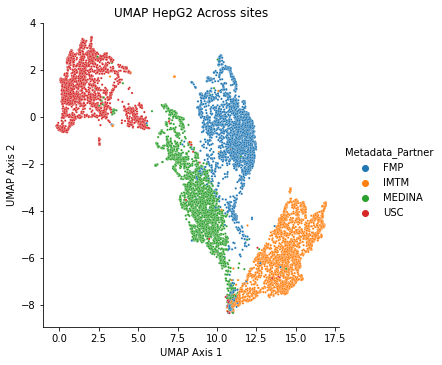

In [17]:
Data_Plot = HepG2_UMAP_2D_Batch

name = "HepG2_Across_Sites"
plot_title = "UMAP HepG2 Across sites"

p1 = sns.relplot(
    data = Data_Plot,
    x="Axis 1", y="Axis 2",
    #palette = color_dict,
    hue = "Metadata_Partner",
    #style = "Metadata_Batch",
    s = 5
)

p1.set(xlabel = "UMAP Axis 1", 
       ylabel = "UMAP Axis 2", 
       title = plot_title)

p1.figure.savefig(figure_path + str(date.today()) + '_' + name + '_UMAP_2D_Plate.png', 
                  transparent=False, 
                  bbox_inches='tight', 
                  dpi = 600)

# Percent pairing

In [18]:
# Restore U2OS and HepG2 dataframes for downstream analysis
FMP_HepG2_Norm_Reduced_Median = HepG2_Norm_Reduced_Median[HepG2_Norm_Reduced_Median["Metadata_Partner"] == "FMP"].copy()
FMP_HepG2_Norm_Reduced_Median['Metadata_EOS_mod'] = 'FMP_' + FMP_HepG2_Norm_Reduced_Median['Metadata_EOS'].astype(str)

IMTM_HepG2_Norm_Reduced_Median = HepG2_Norm_Reduced_Median[HepG2_Norm_Reduced_Median["Metadata_Partner"] == "IMTM"].copy()
IMTM_HepG2_Norm_Reduced_Median['Metadata_EOS_mod'] = 'IMTM_' + IMTM_HepG2_Norm_Reduced_Median['Metadata_EOS'].astype(str)

MEDINA_HepG2_Norm_Reduced_Median = HepG2_Norm_Reduced_Median[HepG2_Norm_Reduced_Median["Metadata_Partner"] == "MEDINA"].copy()
MEDINA_HepG2_Norm_Reduced_Median['Metadata_EOS_mod'] = 'MEDINA_' + MEDINA_HepG2_Norm_Reduced_Median['Metadata_EOS'].astype(str)

USC_HepG2_Norm_Reduced_Median = HepG2_Norm_Reduced_Median[HepG2_Norm_Reduced_Median["Metadata_Partner"] == "USC"].copy()
USC_HepG2_Norm_Reduced_Median['Metadata_EOS_mod'] = 'USC_' + USC_HepG2_Norm_Reduced_Median['Metadata_EOS'].astype(str)


In [19]:
USC_HepG2_Norm_Reduced_Median.head()

,Metadata_EOS,Metadata_Plate,Metadata_Concentration,Metadata_Partner,Nuc_AreaShape_Eccentricity,Nuc_AreaShape_Extent,Nuc_AreaShape_FormFactor,Nuc_AreaShape_MajorAxisLength,Nuc_AreaShape_Orientation,Nuc_AreaShape_Zernike_0_0,...,Cyto_Texture_InverseDifferenceMoment_ER_10_01_256,Cyto_Texture_InverseDifferenceMoment_ER_10_02_256,Cyto_Texture_InverseDifferenceMoment_ER_10_03_256,Cyto_Texture_InverseDifferenceMoment_ER_5_01_256,Cyto_Texture_InverseDifferenceMoment_ER_5_03_256,Cyto_Texture_SumAverage_DNA_10_01_256,Cyto_Texture_SumEntropy_DNA_3_01_256,Cyto_Texture_SumEntropy_ER_3_00_256,Metadata_Object_Count,Metadata_EOS_mod
3,DMSO,B1001,0,USC,0.0,0.0,0.0,3.649858e-15,0.0,0.0,...,-1.999919e-15,0.000000e+00,2.150190e-15,-2.600350e-15,0.000000e+00,0.000000e+00,0.0,0.0,1368.0,USC_DMSO
7,DMSO,B1002,0,USC,0.0,0.0,0.0,0.000000e+00,0.0,0.0,...,-1.749902e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,1150.0,USC_DMSO
11,DMSO,B1003,0,USC,0.0,0.0,0.0,5.149960e-15,0.0,0.0,...,0.000000e+00,0.000000e+00,-2.600025e-15,-2.500008e-15,0.000000e+00,-2.600350e-15,0.0,0.0,1259.5,USC_DMSO
15,DMSO,B1004,0,USC,0.0,0.0,0.0,-5.399977e-15,0.0,0.0,...,0.000000e+00,0.000000e+00,-1.350482e-15,-1.949829e-15,-2.099991e-15,0.000000e+00,0.0,0.0,1249.5,USC_DMSO
19,DMSO,B1005,0,USC,0.0,0.0,0.0,-5.499941e-15,0.0,0.0,...,0.000000e+00,-1.799992e-15,2.450080e-15,0.000000e+00,1.649722e-15,0.000000e+00,0.0,0.0,1249.5,USC_DMSO


In [20]:
import numpy as np

def compute_percent_pairing(modality_1_df, modality_2_df, modality_1_perturbation, modality_2_perturbation):

    signal = UTIL.correlation_between_modalities(modality_1_df,
                                                 modality_2_df,
                                                 modality_1_perturbation,
                                                 modality_2_perturbation,
                                                 'Metadata_EOS',
                                                 'Metadata_EOS_mod',
                                                 "partner_site")

    null = UTIL.null_correlation_between_modalities(modality_1_df,
                                                    modality_2_df,
                                                    modality_1_perturbation,
                                                    modality_2_perturbation,
                                                    'Metadata_EOS',
                                                    'Metadata_EOS_mod',
                                                    10000,
                                                    "partner_site")

    prop_5_95, value_95 = UTIL.percent_score(null, signal, how='right')

    perc_95 = np.nanpercentile(null, 95)
    above_threshold = signal > perc_95

    description_string = modality_1_perturbation + ' vs. ' + modality_2_perturbation

    corr_df = pd.DataFrame()
    corr_df = corr_df.append({'Description': description_string,
                           'Pairing':signal,
                           'Null_Pairing':null,
                           'Percent_Pairing':'%.1f'%prop_5_95,
                           'Value_95':value_95}, ignore_index=True)

    print(corr_df[['Description', 'Percent_Pairing']].to_markdown(index=False))

    UTIL.distribution_plot(df=corr_df, metric="Percent Pairing")

    plt.savefig(figure_path + str(date.today()) +'_' + modality_1_perturbation + '_vs_' + modality_2_perturbation + '_Percent_Pairing.pdf',
                transparent=False, 
                bbox_inches='tight',
                dpi = 600)
    
    return corr_df

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description   |   Percent_Pairing |
|:--------------|------------------:|
| FMP vs. IMTM  |              35.3 |


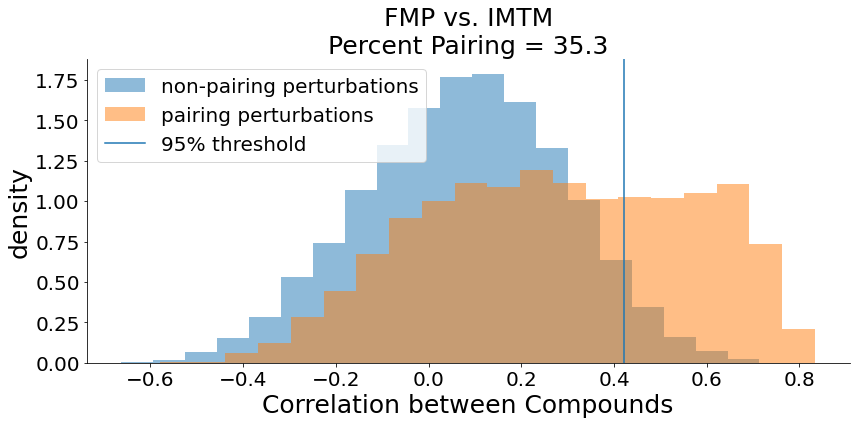

In [21]:
corr_df = compute_percent_pairing(FMP_HepG2_Norm_Reduced_Median, IMTM_HepG2_Norm_Reduced_Median, "FMP", "IMTM")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description    |   Percent_Pairing |
|:---------------|------------------:|
| FMP vs. MEDINA |              30.2 |


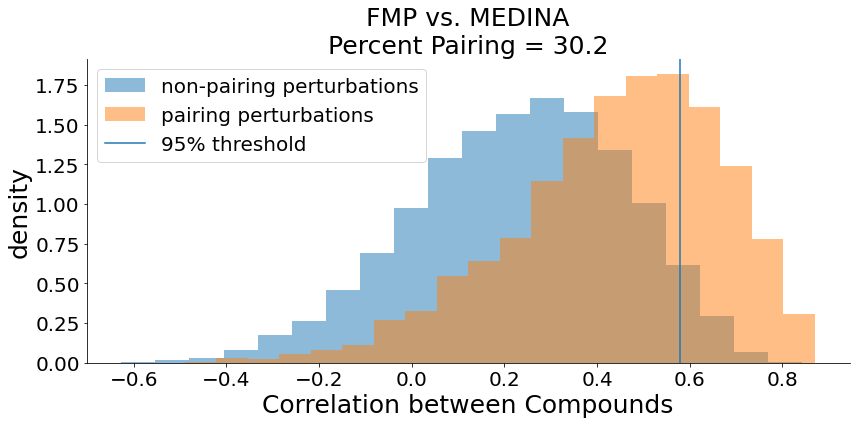

In [22]:
corr_df = compute_percent_pairing(FMP_HepG2_Norm_Reduced_Median, MEDINA_HepG2_Norm_Reduced_Median, "FMP", "MEDINA")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description   |   Percent_Pairing |
|:--------------|------------------:|
| FMP vs. USC   |              29.7 |


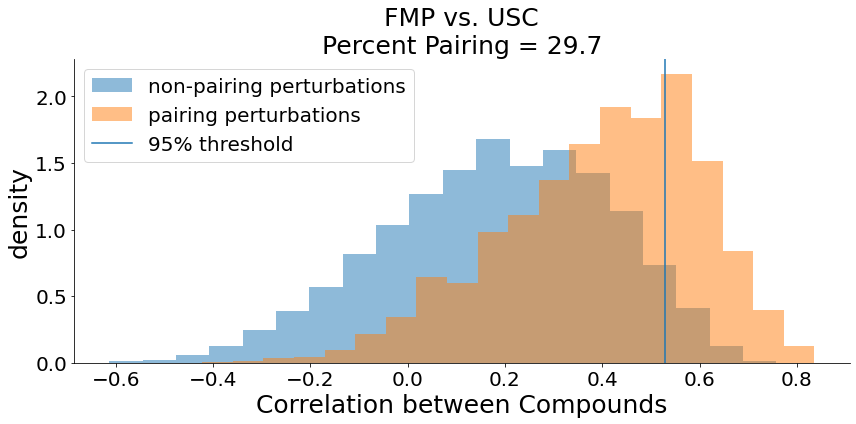

In [23]:
corr_df = compute_percent_pairing(FMP_HepG2_Norm_Reduced_Median, USC_HepG2_Norm_Reduced_Median, "FMP", "USC")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description     |   Percent_Pairing |
|:----------------|------------------:|
| IMTM vs. MEDINA |              30.9 |


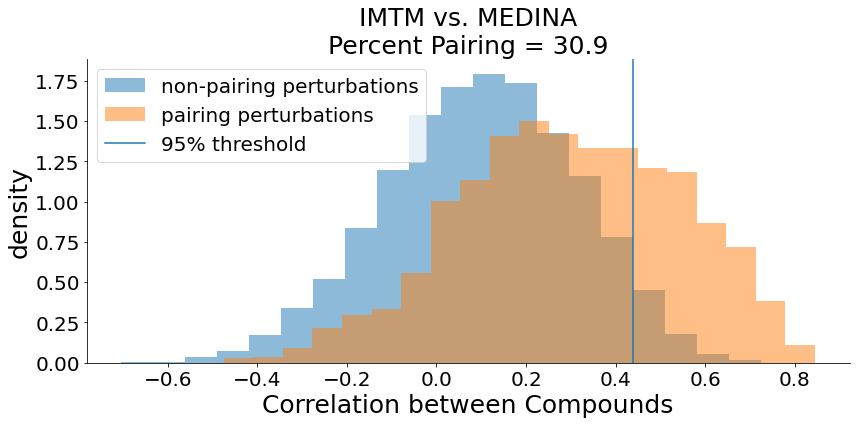

In [24]:
corr_df = compute_percent_pairing(IMTM_HepG2_Norm_Reduced_Median, MEDINA_HepG2_Norm_Reduced_Median, "IMTM", "MEDINA")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description   |   Percent_Pairing |
|:--------------|------------------:|
| IMTM vs. USC  |              28.4 |


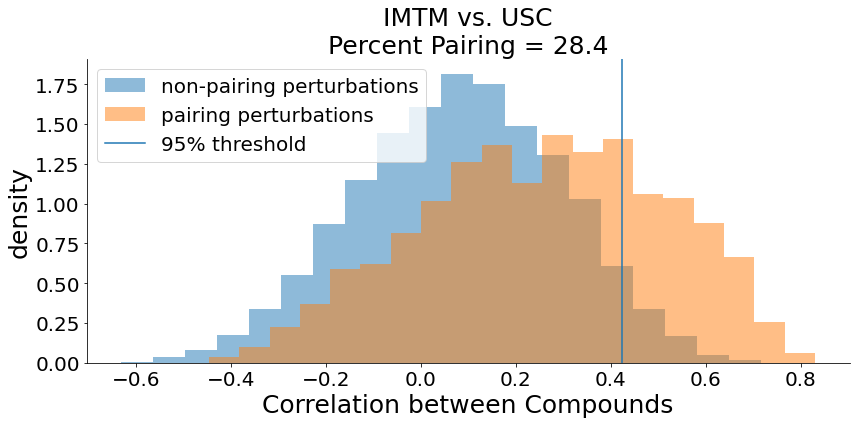

In [25]:
corr_df = compute_percent_pairing(IMTM_HepG2_Norm_Reduced_Median, USC_HepG2_Norm_Reduced_Median, "IMTM", "USC")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description    |   Percent_Pairing |
|:---------------|------------------:|
| MEDINA vs. USC |              28.7 |


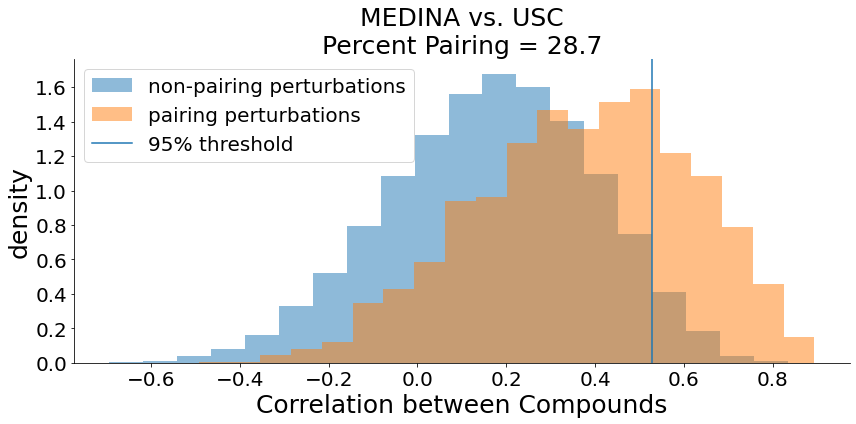

In [26]:
corr_df = compute_percent_pairing(MEDINA_HepG2_Norm_Reduced_Median, USC_HepG2_Norm_Reduced_Median, "MEDINA", "USC")

# Compute activity and filter

In [27]:
FMP_HepG2_Norm_Reduced_Median.head()

,Metadata_EOS,Metadata_Plate,Metadata_Concentration,Metadata_Partner,Nuc_AreaShape_Eccentricity,Nuc_AreaShape_Extent,Nuc_AreaShape_FormFactor,Nuc_AreaShape_MajorAxisLength,Nuc_AreaShape_Orientation,Nuc_AreaShape_Zernike_0_0,...,Cyto_Texture_InverseDifferenceMoment_ER_10_01_256,Cyto_Texture_InverseDifferenceMoment_ER_10_02_256,Cyto_Texture_InverseDifferenceMoment_ER_10_03_256,Cyto_Texture_InverseDifferenceMoment_ER_5_01_256,Cyto_Texture_InverseDifferenceMoment_ER_5_03_256,Cyto_Texture_SumAverage_DNA_10_01_256,Cyto_Texture_SumEntropy_DNA_3_01_256,Cyto_Texture_SumEntropy_ER_3_00_256,Metadata_Object_Count,Metadata_EOS_mod
0,DMSO,B1001,0,FMP,0.0,0.0,0.0,0.000000e+00,0.0,0.0,...,0.000000e+00,2.200497e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.0,-2.700097e-15,0.000000e+00,925.5,FMP_DMSO
4,DMSO,B1002,0,FMP,0.0,0.0,0.0,0.000000e+00,0.0,0.0,...,1.199995e-15,0.000000e+00,-2.499737e-15,0.000000e+00,-2.399990e-15,0.0,0.000000e+00,0.000000e+00,929.0,FMP_DMSO
8,DMSO,B1003,0,FMP,0.0,0.0,0.0,4.899998e-15,0.0,0.0,...,0.000000e+00,-1.949829e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.0,-2.249936e-15,0.000000e+00,895.5,FMP_DMSO
12,DMSO,B1004,0,FMP,0.0,0.0,0.0,0.000000e+00,0.0,0.0,...,-1.349615e-15,-2.050009e-15,1.950046e-15,1.700029e-15,0.000000e+00,0.0,0.000000e+00,0.000000e+00,914.5,FMP_DMSO
16,DMSO,B1005,0,FMP,0.0,0.0,0.0,0.000000e+00,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,3.150258e-15,-2.399990e-15,0.0,-3.315941e-15,5.999975e-15,937.0,FMP_DMSO


In [28]:
key_col = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner", 'Metadata_EOS_mod']

FMP_HepG2_active, FMP_HepG2_low_active = UTIL.remove_low_active(FMP_HepG2_Norm_Reduced_Median, 
                                                   key_col,
                                                   3.0, 
                                                   5.0)

print("FMP HepG2 active:", len(FMP_HepG2_active["Metadata_EOS"].unique()))
print("FMP HepG2 low-active:", len(FMP_HepG2_low_active["Metadata_EOS"].unique()))

FMP HepG2 active: 993
FMP HepG2 low-active: 1469


In [29]:
IMTM_HepG2_active, IMTM_HepG2_low_active = UTIL.remove_low_active(IMTM_HepG2_Norm_Reduced_Median, 
                                                   key_col,
                                                   3.0, 
                                                   5.0)

print("HepG2 active:", len(IMTM_HepG2_active["Metadata_EOS"].unique()))
print("HepG2 low-active:", len(IMTM_HepG2_low_active["Metadata_EOS"].unique()))

HepG2 active: 766
HepG2 low-active: 1693


In [30]:
MEDINA_HepG2_active, MEDINA_HepG2_low_active = UTIL.remove_low_active(MEDINA_HepG2_Norm_Reduced_Median, 
                                                   key_col,
                                                   3.0, 
                                                   5.0)

print("HepG2 active:", len(MEDINA_HepG2_active["Metadata_EOS"].unique()))
print("HepG2 low-active:", len(MEDINA_HepG2_low_active["Metadata_EOS"].unique()))

HepG2 active: 890
HepG2 low-active: 1577


In [31]:
USC_HepG2_active, USC_HepG2_low_active = UTIL.remove_low_active(USC_HepG2_Norm_Reduced_Median, 
                                                   key_col,
                                                   3.0, 
                                                   5.0)

print("HepG2 active:", len(USC_HepG2_active["Metadata_EOS"].unique()))
print("HepG2 low-active:", len(USC_HepG2_low_active["Metadata_EOS"].unique()))

HepG2 active: 716
HepG2 low-active: 1751


# Remove low active to perform percent replication to remove low replicating compounds

In [32]:
# # Restore U2OS and HepG2 dataframes for downstream analysis
FMP_HepG2_Norm_Reduced = HepG2_reduced[HepG2_reduced["Metadata_Partner"] == "FMP"].copy()
FMP_HepG2_Norm_Reduced_active = FMP_HepG2_Norm_Reduced[
    (FMP_HepG2_Norm_Reduced['Metadata_EOS'].isin(FMP_HepG2_active['Metadata_EOS']))]

In [33]:
FMP_HepG2_active_replicating, FMP_HepG2_active_corr_replicating_df = UTIL.remove_non_reproducible(
    FMP_HepG2_Norm_Reduced_active, 
    n_samples = 10000, 
    n_replicates = 4, 
    ID_col = "Metadata_EOS", 
    description = "Data_50")

| Description   |   Percent_Replicating |
|:--------------|----------------------:|
| Data_50       |                  89.8 |
Nonreplicating conditions removed with threshold 0.48
Old shape (4043, 499)
New shape (3663, 499)


/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/utility_functions.py:390: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_replicating_df = corr_replicating_df.append({'Description': description,


In [34]:
IMTM_HepG2_Norm_Reduced = HepG2_reduced[HepG2_reduced["Metadata_Partner"] == "IMTM"].copy()

IMTM_HepG2_Norm_Reduced_active = IMTM_HepG2_Norm_Reduced[
    (IMTM_HepG2_Norm_Reduced['Metadata_EOS'].isin(IMTM_HepG2_active['Metadata_EOS']))]

In [35]:
IMTM_HepG2_active_replicating, IMTM_HepG2_active_corr_replicating_df = UTIL.remove_non_reproducible(
    IMTM_HepG2_Norm_Reduced_active, 
    n_samples = 10000, 
    n_replicates = 4, 
    ID_col = "Metadata_EOS", 
    description = "Data_50")

| Description   |   Percent_Replicating |
|:--------------|----------------------:|
| Data_50       |                  84.9 |
Nonreplicating conditions removed with threshold 0.42
Old shape (3127, 499)
New shape (2702, 499)


/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/utility_functions.py:390: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_replicating_df = corr_replicating_df.append({'Description': description,


In [36]:
MEDINA_HepG2_Norm_Reduced = HepG2_reduced[HepG2_reduced["Metadata_Partner"] == "MEDINA"].copy()

MEDINA_HepG2_Norm_Reduced_active = MEDINA_HepG2_Norm_Reduced[
    (MEDINA_HepG2_Norm_Reduced['Metadata_EOS'].isin(MEDINA_HepG2_active['Metadata_EOS']))]

In [37]:
MEDINA_HepG2_active_replicating, MEDINA_HepG2_active_corr_replicating_df = UTIL.remove_non_reproducible(
    MEDINA_HepG2_Norm_Reduced_active, 
    n_samples = 10000, 
    n_replicates = 4, 
    ID_col = "Metadata_EOS", 
    description = "Data_50")

| Description   |   Percent_Replicating |
|:--------------|----------------------:|
| Data_50       |                  84.5 |
Nonreplicating conditions removed with threshold 0.5
Old shape (3647, 499)
New shape (3110, 499)


/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/utility_functions.py:390: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_replicating_df = corr_replicating_df.append({'Description': description,


In [38]:
USC_HepG2_Norm_Reduced = HepG2_reduced[HepG2_reduced["Metadata_Partner"] == "USC"].copy()

USC_HepG2_Norm_Reduced_active = USC_HepG2_Norm_Reduced[
    (USC_HepG2_Norm_Reduced['Metadata_EOS'].isin(USC_HepG2_active['Metadata_EOS']))]

In [39]:
USC_HepG2_active_replicating, USC_HepG2_active_corr_replicating_df = UTIL.remove_non_reproducible(
    USC_HepG2_Norm_Reduced_active, 
    n_samples = 10000, 
    n_replicates = 4, 
    ID_col = "Metadata_EOS", 
    description = "Data_50")

| Description   |   Percent_Replicating |
|:--------------|----------------------:|
| Data_50       |                  93.3 |
Nonreplicating conditions removed with threshold 0.43
Old shape (2964, 499)
New shape (2776, 499)


/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/utility_functions.py:390: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_replicating_df = corr_replicating_df.append({'Description': description,


# Filter compounds of consensus profiles

In [40]:
FMP_HepG2_Norm_Reduced_Median_active_replicating = FMP_HepG2_Norm_Reduced_Median[
    (FMP_HepG2_Norm_Reduced_Median['Metadata_EOS'].isin(FMP_HepG2_active_replicating['Metadata_EOS']))]

In [41]:
IMTM_HepG2_Norm_Reduced_Median_active_replicating = IMTM_HepG2_Norm_Reduced_Median[
    (IMTM_HepG2_Norm_Reduced_Median['Metadata_EOS'].isin(IMTM_HepG2_active_replicating['Metadata_EOS']))]

In [42]:
MEDINA_HepG2_Norm_Reduced_Median_active_replicating = MEDINA_HepG2_Norm_Reduced_Median[
    (MEDINA_HepG2_Norm_Reduced_Median['Metadata_EOS'].isin(MEDINA_HepG2_active_replicating['Metadata_EOS']))]

In [43]:
USC_HepG2_Norm_Reduced_Median_active_replicating = USC_HepG2_Norm_Reduced_Median[
    (USC_HepG2_Norm_Reduced_Median['Metadata_EOS'].isin(USC_HepG2_active_replicating['Metadata_EOS']))]

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description   |   Percent_Pairing |
|:--------------|------------------:|
| FMP vs. IMTM  |              67.1 |


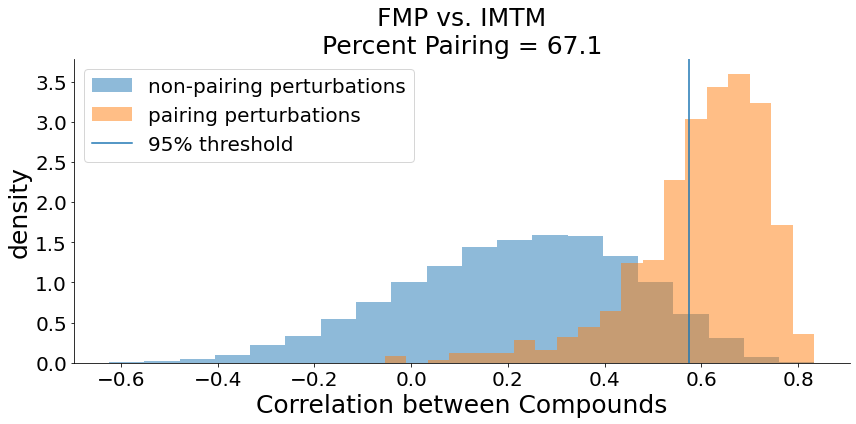

In [44]:
corr_df = compute_percent_pairing(FMP_HepG2_Norm_Reduced_Median_active_replicating, IMTM_HepG2_Norm_Reduced_Median_active_replicating, "FMP", "IMTM")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description    |   Percent_Pairing |
|:---------------|------------------:|
| FMP vs. MEDINA |              55.3 |


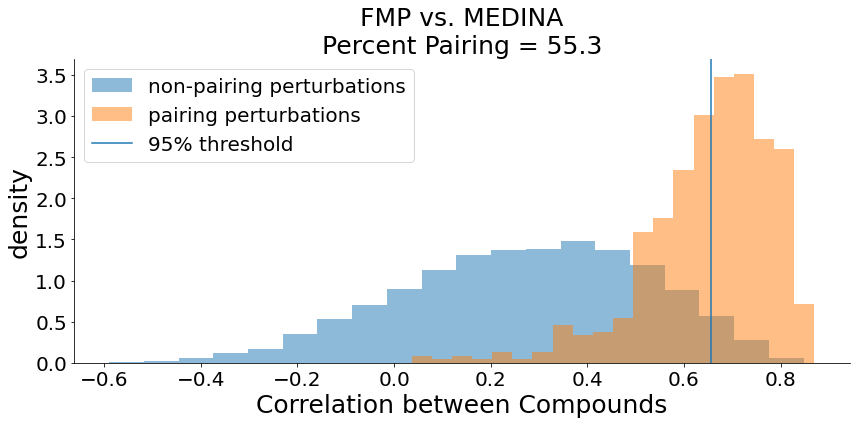

In [45]:
corr_df = compute_percent_pairing(FMP_HepG2_Norm_Reduced_Median_active_replicating, MEDINA_HepG2_Norm_Reduced_Median_active_replicating, "FMP", "MEDINA")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description   |   Percent_Pairing |
|:--------------|------------------:|
| FMP vs. USC   |              57.2 |


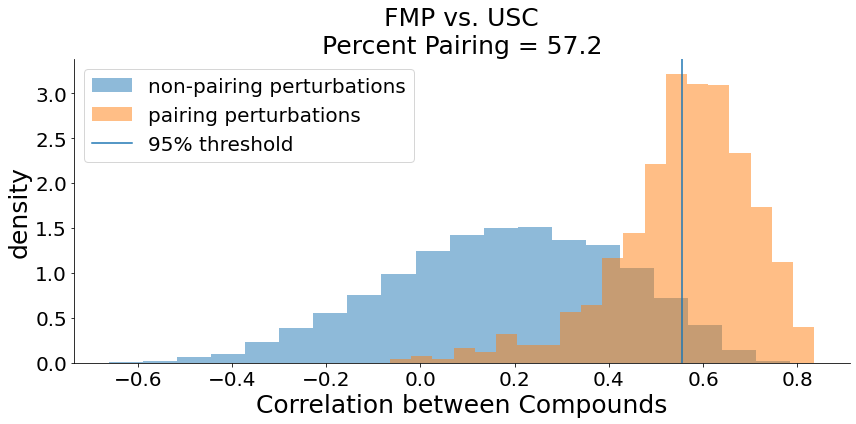

In [46]:
corr_df = compute_percent_pairing(FMP_HepG2_Norm_Reduced_Median_active_replicating, USC_HepG2_Norm_Reduced_Median_active_replicating, "FMP", "USC")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description     |   Percent_Pairing |
|:----------------|------------------:|
| IMTM vs. MEDINA |              54.8 |


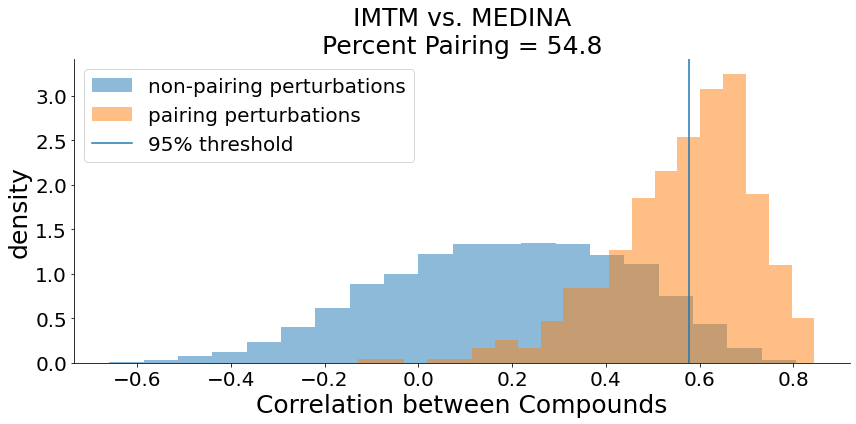

In [47]:
corr_df = compute_percent_pairing(IMTM_HepG2_Norm_Reduced_Median_active_replicating, MEDINA_HepG2_Norm_Reduced_Median_active_replicating, "IMTM", "MEDINA")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description   |   Percent_Pairing |
|:--------------|------------------:|
| IMTM vs. USC  |              56.5 |


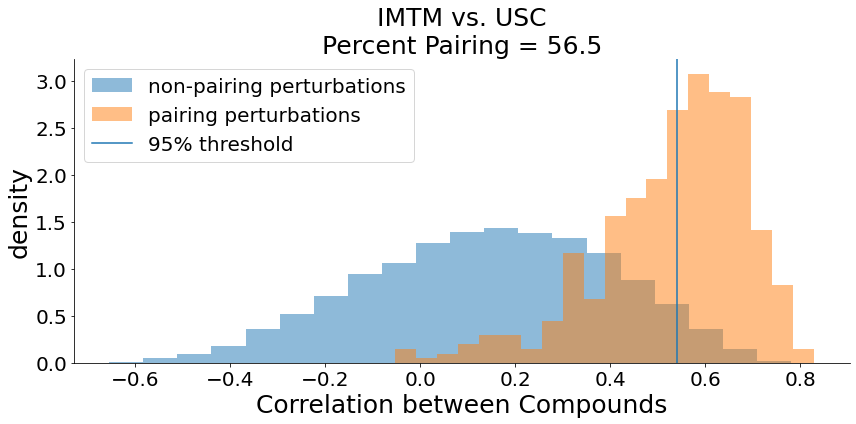

In [48]:
corr_df = compute_percent_pairing(IMTM_HepG2_Norm_Reduced_Median_active_replicating, USC_HepG2_Norm_Reduced_Median_active_replicating, "IMTM", "USC")

<ipython-input-20-5b486f64ecec>:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description    |   Percent_Pairing |
|:---------------|------------------:|
| MEDINA vs. USC |              62.1 |


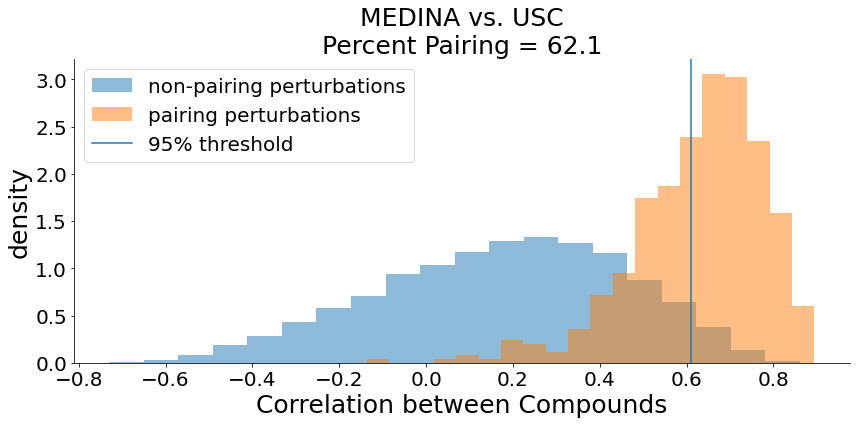

In [49]:
corr_df = compute_percent_pairing(MEDINA_HepG2_Norm_Reduced_Median_active_replicating, USC_HepG2_Norm_Reduced_Median_active_replicating, "MEDINA", "USC")

# Percent matching

In [50]:
### load file
data_annotations = pd.read_csv(annot_path + '2022-05-13_Labels_Bioactives_Combined_with_Broad_MeSH_JUMP-CP.csv')
data_annotations.shape

annot_columns = ['pdid', 'EOS', 'Broad_MOA']
data_annotations_moa = data_annotations.loc[:, annot_columns]

data_annotations_moa['Broad_MOA'] = data_annotations_moa['Broad_MOA'].str.split(';')
data_annotations_moa_full = data_annotations_moa.explode('Broad_MOA', ignore_index=True)

value_counts_MOA = data_annotations_moa_full['Broad_MOA'].value_counts()
MOA_keep = value_counts_MOA[value_counts_MOA >= 3].index
annotations_moa_filtered = data_annotations_moa_full[data_annotations_moa_full['Broad_MOA'].isin(MOA_keep)]

annotations_moa_filtered = annotations_moa_filtered.rename(columns={'pdid': 'Metadata_pdid', 
                                    'EOS': 'Metadata_EOS', 
                                    'Broad_MOA': 'Metadata_Broad_MOA'
                                    })

In [60]:
# Merge in annotation colums
FMP_HepG2_annotated = pd.merge(annotations_moa_filtered, FMP_HepG2_Norm_Reduced_Median_active_replicating, on='Metadata_EOS', how='left')
FMP_HepG2_annotated_cleaned = FMP_HepG2_annotated.dropna()

In [61]:
# Merge in annotation colums
IMTM_HepG2_annotated = pd.merge(annotations_moa_filtered, IMTM_HepG2_Norm_Reduced_Median_active_replicating, on='Metadata_EOS', how='left')
IMTM_HepG2_annotated_cleaned = IMTM_HepG2_annotated.dropna()

In [62]:
# Merge in annotation colums
MEDINA_HepG2_annotated = pd.merge(annotations_moa_filtered, MEDINA_HepG2_Norm_Reduced_Median_active_replicating, on='Metadata_EOS', how='left')
MEDINA_HepG2_annotated_cleaned = MEDINA_HepG2_annotated.dropna()

In [63]:
# Merge in annotation colums
USC_HepG2_annotated = pd.merge(annotations_moa_filtered, USC_HepG2_Norm_Reduced_Median_active_replicating, on='Metadata_EOS', how='left')
USC_HepG2_annotated_cleaned = USC_HepG2_annotated.dropna()

In [65]:
def compute_percent_matching_modalities(modality_1_df, modality_2_df, modality_1_perturbation, modality_2_perturbation):

    signal = UTIL.correlation_between_modalities(modality_1_df,
                                                 modality_2_df,
                                                 modality_1_perturbation,
                                                 modality_2_perturbation,
                                                 'Metadata_EOS',
                                                 'Metadata_Broad_MOA',
                                                 "partner_site")

    null = UTIL.null_correlation_between_modalities(modality_1_df,
                                                    modality_2_df,
                                                    modality_1_perturbation,
                                                    modality_2_perturbation,
                                                    'Metadata_EOS',
                                                    'Metadata_Broad_MOA',
                                                    10000,
                                                    "partner_site")

    prop_5_95, value_95 = UTIL.percent_score(null, signal, how='right')

    perc_95 = np.nanpercentile(null, 95)
    above_threshold = signal > perc_95

    description_string = modality_1_perturbation + ' vs. ' + modality_2_perturbation

    corr_df = pd.DataFrame()
    corr_df = corr_df.append({'Description': description_string,
                           'Pairing':signal,
                           'Null_Pairing':null,
                           'Percent_Pairing':'%.1f'%prop_5_95,
                           'Value_95':value_95}, ignore_index=True)

    print(corr_df[['Description', 'Percent_Pairing']].to_markdown(index=False))

    UTIL.distribution_plot(df=corr_df, metric="Percent Pairing")

    plt.savefig(figure_path + str(date.today()) +'_' + modality_1_perturbation + '_vs_' + modality_2_perturbation + '_Percent_Pairing.pdf',
                transparent=False, 
                bbox_inches='tight',
                dpi = 600)
    
    return corr_df

<ipython-input-65-8c978096b02d>:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description   |   Percent_Pairing |
|:--------------|------------------:|
| FMP vs. IMTM  |              72.8 |


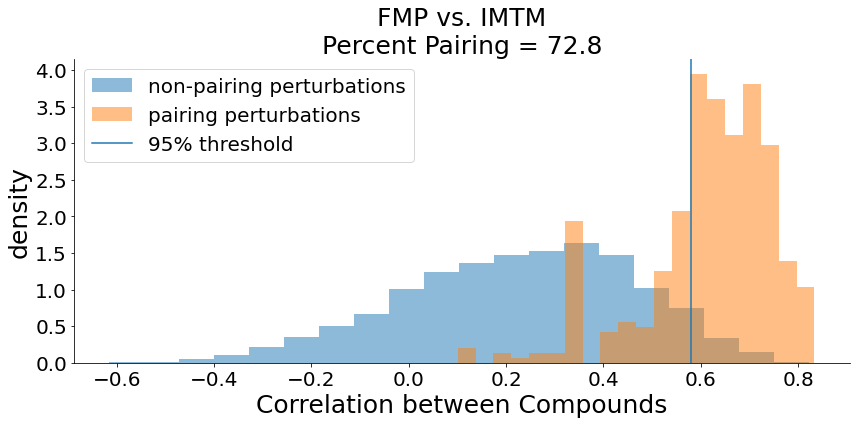

In [66]:
corr_df = compute_percent_matching_modalities(FMP_HepG2_annotated_cleaned, IMTM_HepG2_annotated_cleaned, "FMP", "IMTM")

<ipython-input-65-8c978096b02d>:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description    |   Percent_Pairing |
|:---------------|------------------:|
| FMP vs. MEDINA |              59.6 |


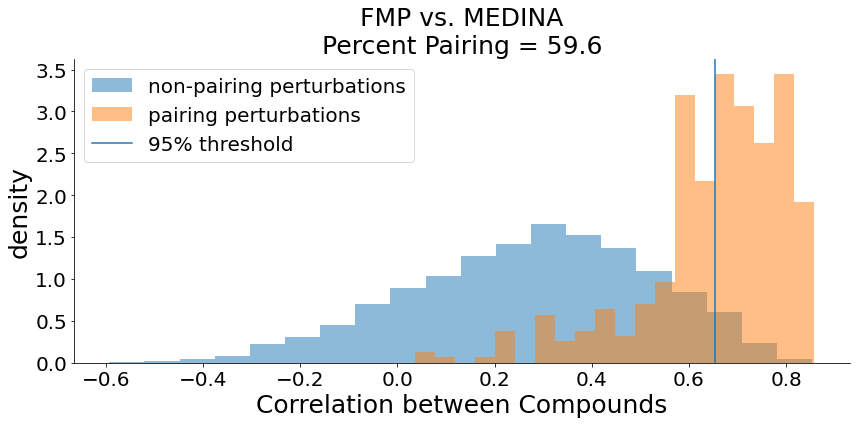

In [71]:
corr_df = compute_percent_matching_modalities(FMP_HepG2_annotated_cleaned, MEDINA_HepG2_annotated_cleaned, "FMP", "MEDINA")

<ipython-input-65-8c978096b02d>:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description   |   Percent_Pairing |
|:--------------|------------------:|
| FMP vs. USC   |              49.3 |


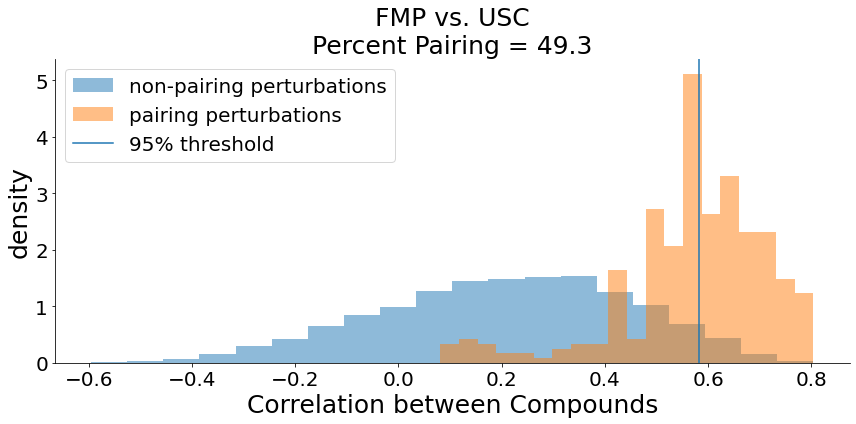

In [67]:
corr_df = compute_percent_matching_modalities(FMP_HepG2_annotated_cleaned, USC_HepG2_annotated_cleaned, "FMP", "USC")

<ipython-input-65-8c978096b02d>:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description     |   Percent_Pairing |
|:----------------|------------------:|
| IMTM vs. MEDINA |              49.4 |


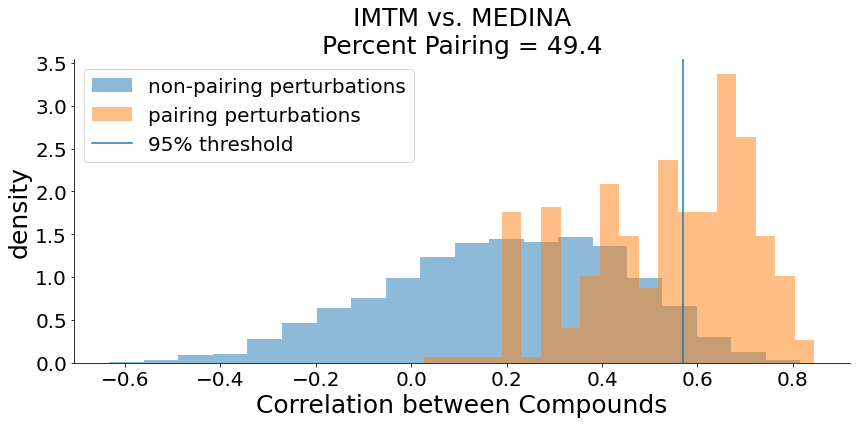

In [68]:
corr_df = compute_percent_matching_modalities(IMTM_HepG2_annotated_cleaned, MEDINA_HepG2_annotated_cleaned, "IMTM", "MEDINA")

<ipython-input-65-8c978096b02d>:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description   |   Percent_Pairing |
|:--------------|------------------:|
| IMTM vs. USC  |              45.9 |


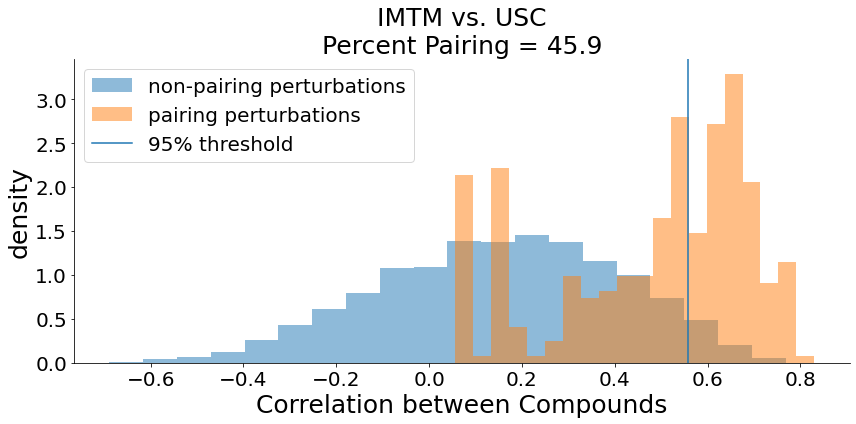

In [69]:
corr_df = compute_percent_matching_modalities(IMTM_HepG2_annotated_cleaned, USC_HepG2_annotated_cleaned, "IMTM", "USC")

<ipython-input-65-8c978096b02d>:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corr_df = corr_df.append({'Description': description_string,


| Description    |   Percent_Pairing |
|:---------------|------------------:|
| MEDINA vs. USC |              58.8 |


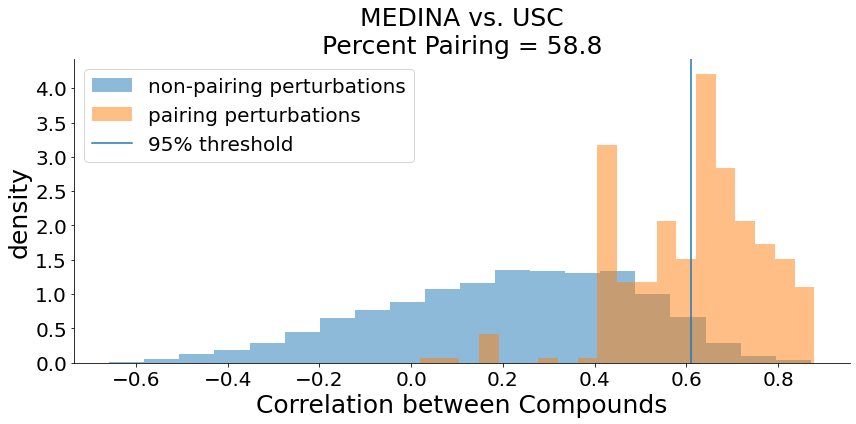

In [70]:
corr_df = compute_percent_matching_modalities(MEDINA_HepG2_annotated_cleaned, USC_HepG2_annotated_cleaned, "MEDINA", "USC")